<a href="https://colab.research.google.com/github/diego-andrade279/Aprendizado-de-maquina-/blob/main/PROJETO_CIENCIA_DE_DADOS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 PROJETO: ANÁLISE DE DADOS DO BOLSA FAMÍLIA (2025)

**Disciplina:** Ciência de Dados
**Ferramentas:** Python, Pandas, Seaborn, Plotly
**Fonte de Dados:** API de Dados Abertos (MDS) e GitHub (Geolocalização)

---
**OBJETIVO DO ESTUDO:**
Realizar uma análise exploratória completa sobre a distribuição de renda do programa Bolsa Família em Janeiro de 2025. O estudo cruza dados financeiros com informações geográficas para identificar padrões regionais, desigualdades e consistência estatística nos repasses.

## 1. Coleta e Tratamento de Dados (ETL)

Nesta etapa, realizamos a importação das bibliotecas necessárias e a conexão com a API do Ministério do Desenvolvimento Social.
Também realizamos um **cruzamento de dados (Merge)**:
1.  Baixamos os dados financeiros (que possuem o Código IBGE).
2.  Baixamos uma tabela auxiliar com Latitude e Longitude dos municípios.
3.  Tratamos a diferença de formatação (6 dígitos vs 7 dígitos) para unir as tabelas com sucesso.

# Importaçao de bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns
import requests
import io

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns
import requests
import io

In [3]:
# Configuração visual para os gráficos ficarem bonitos
sns.set_theme(style="whitegrid")

# Baixando e lendos os arquivos

1.   Baixa dados do Bolsa Família: Ela define uma URL para a API de Dados Abertos do Ministério do Desenvolvimento Social (MDS) e usa requests para baixar os dados brutos sobre o Bolsa Família para o ano de 2025. Os dados são lidos diretamente para um DataFrame df do pandas.

2.   Renomeia Colunas: As colunas do DataFrame df são renomeadas para nomes mais amigáveis e descritivos.

3. Baixa Dados de Geolocalização: Define outra URL para um repositório no GitHub que contém dados de geolocalização de municípios brasileiros. Esses dados são lidos em um DataFrame df_geo.

4. Limpa Dados de Geolocalização: Algumas colunas irrelevantes (capital, codigo_uf, siafi_id, ddd, fuso_horario) são removidas de df_geo, e as restantes são renomeadas.
5. Trata Código IBGE: O código IBGE na tabela de geolocalização (df_geo) tem um dígito a mais que na tabela do Bolsa Família (df). Esta linha remove esse dígito extra para que as duas tabelas possam ser unidas corretamente.

6. Mescla os DataFrames: Os dois DataFrames (df e df_geo) são mesclados usando o Código_IBGE como chave, combinando as informações financeiras do Bolsa Família com a Latitude e Longitude de cada município. A coluna Codigo_ibge duplicada é então removida.

7. Exibe as Primeiras Linhas: Por fim, df.head() mostra as primeiras 5 linhas do DataFrame resultante para verificar se a mesclagem foi bem-sucedida e os dados estão como esperado.







In [4]:
url = "https://aplicacoes.mds.gov.br/sagi/servicos/misocial/?fq=anomes_s:2025*&fl=codigo_ibge%2Canomes_s%2Cqtd_familias_beneficiarias_bolsa_familia_s%2Cvalor_repassado_bolsa_familia_s%2Cpbf_vlr_medio_benef_f&fq=valor_repassado_bolsa_familia_s%3A*&q=*%3A*&rows=100000&sort=anomes_s%20desc%2C%20codigo_ibge%20asc&wt=csv"
response = requests.get(url).content
df = pd.read_csv(io.StringIO(response.decode('utf-8')))
df.columns = ['Codigo_IBGE', 'Anos_Mes', 'Quantidade_Famílias_Beneficiárias', 'Valor_Repassado_Bolsa_Família', 'PBF_Vlr_Médio_Beneficiário']

# baixando dados de Geolocalizaçao de municipios
url_geo = "https://raw.githubusercontent.com/kelvins/municipios-brasileiros/main/csv/municipios.csv"
df_geo = pd.read_csv(url_geo)
df_geo.drop(['capital', 'codigo_uf', 'siafi_id', 'ddd', 'fuso_horario'], axis=1, inplace=True)
df_geo.columns = ['Codigo_ibge', 'Nome', 'Latitude','Longitude']

#removendo digito a mais no codigo do municipio da tabela 2
df_geo['Codigo_ibge'] = df_geo['Codigo_ibge']//10

# mesclando dados das duas tabelas baixadas
df = pd.merge(df, df_geo, left_on='Codigo_IBGE', right_on='Codigo_ibge', how='inner')
df.drop('Codigo_ibge', axis=1, inplace=True)
df.head()

,Codigo_IBGE,Anos_Mes,Quantidade_Famílias_Beneficiárias,Valor_Repassado_Bolsa_Família,PBF_Vlr_Médio_Beneficiário,Nome,Latitude,Longitude
0,110001,202512,1521,1040611.0,714.71,Alta Floresta D'Oeste,-11.92830,-61.9953
1,110002,202512,7224,4944718.0,710.75,Ariquemes,-9.90571,-63.0325
2,110003,202512,324,226174.0,727.25,Cabixi,-13.49450,-60.5520
3,110004,202512,5539,3728813.0,708.63,Cacoal,-11.43430,-61.4562
4,110005,202512,1112,771917.0,728.91,Cerejeiras,-13.18700,-60.8168


#DF.INFO() Informaçoes sobre o data frame


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66842 entries, 0 to 66841
Data columns (total 8 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Codigo_IBGE                        66842 non-null  int64  
 1   Anos_Mes                           66842 non-null  int64  
 2   Quantidade_Famílias_Beneficiárias  66842 non-null  int64  
 3   Valor_Repassado_Bolsa_Família      66842 non-null  float64
 4   PBF_Vlr_Médio_Beneficiário         66842 non-null  float64
 5   Nome                               66842 non-null  object 
 6   Latitude                           66842 non-null  float64
 7   Longitude                          66842 non-null  float64
dtypes: float64(4), int64(3), object(1)
memory usage: 4.1+ MB


# Renomeando Colunas  e formatando os Dados
  Nesta etapa, você está renomeando todas as colunas do seu DataFrame. Isso é feito atribuindo uma nova lista de nomes à propriedade df.columns. É uma prática comum tornar os nomes das colunas mais legíveis e padronizados, o que facilita o trabalho futuro com os dados.

O print(df.columns) apenas exibe os novos nomes das colunas para confirmar a alteração.


In [6]:
df.columns = ['Código IBGE', 'Anos_Mes', 'Quantidade_Famílias_Beneficiárias', 'Valor_Repassado_Bolsa_Família', 'PBF_Vlr_Médio_Beneficiário','Nome', 'Latitude', 'Longitude']
print(df.columns)


Index(['Código IBGE', 'Anos_Mes', 'Quantidade_Famílias_Beneficiárias',
       'Valor_Repassado_Bolsa_Família', 'PBF_Vlr_Médio_Beneficiário', 'Nome',
       'Latitude', 'Longitude'],
      dtype='object')


In [7]:
df['Ano'] = df['Anos_Mes'].astype(str).str[:4]
df['Mes'] = df['Anos_Mes'].astype(str).str[-2:]
df.drop('Anos_Mes', axis=1, inplace=True)
df.head()

,Código IBGE,Quantidade_Famílias_Beneficiárias,Valor_Repassado_Bolsa_Família,PBF_Vlr_Médio_Beneficiário,Nome,Latitude,Longitude,Ano,Mes
0,110001,1521,1040611.0,714.71,Alta Floresta D'Oeste,-11.92830,-61.9953,2025,12
1,110002,7224,4944718.0,710.75,Ariquemes,-9.90571,-63.0325,2025,12
2,110003,324,226174.0,727.25,Cabixi,-13.49450,-60.5520,2025,12
3,110004,5539,3728813.0,708.63,Cacoal,-11.43430,-61.4562,2025,12
4,110005,1112,771917.0,728.91,Cerejeiras,-13.18700,-60.8168,2025,12


Esta célula realiza uma importante transformação nos dados de tempo:

Extração do Ano: A coluna Anos_Mes (que provavelmente está no formato AAAAMMDD ou AAAAMM) é convertida para string (.astype(str)) e os primeiros 4 caracteres são extraídos para criar uma nova coluna Ano. Por exemplo, 202512 se torna 2025.
Extração do Mês: De forma semelhante, os últimos 2 caracteres da coluna Anos_Mes são extraídos para criar uma nova coluna Mes. Por exemplo, 202512 se torna 12.
Remoção da Coluna Original: Após extrair o ano e o mês em colunas separadas e mais úteis, a coluna Anos_Mes original é removida do DataFrame usando df.drop(). O axis=1 indica que estamos removendo uma coluna e inplace=True faz a modificação diretamente no DataFrame df.
df.head(): Novamente, mostra as primeiras linhas do DataFrame para verificar se as novas colunas foram criadas corretamente e a coluna antiga foi removida.
Essas etapas de inspeção e formatação são cruciais para garantir que os dados estejam limpos, organizados e prontos para a análise.

# Distribuiçao Media por municipio
  "A análise geoespacial permitiu identificar que, embora as capitais (como São Paulo e Rio de Janeiro) concentrem o maior volume absoluto de beneficiários (representado pelo tamanho dos marcadores), os maiores valores médios per capita (representados pela escala de cor quente) estão frequentemente localizados em municípios menores das regiões Norte e Nordeste, indicando a função de redistribuição de renda do programa nessas localidades."

In [8]:
import plotly.express as px

# --- GERANDO O MAPA INTERATIVO ---
print("Gerando o mapa... isso pode levar uns segundos.")

# Criando o gráfico
fig = px.scatter_mapbox(
    df,
    lat="Latitude",
    lon="Longitude",

    # O que aparece quando passa o mouse
    hover_name="Nome",
    hover_data={
        "Latitude": False, "Longitude": False, # Esconde lat/lon (ninguém precisa ver)
        "PBF_Vlr_Médio_Beneficiário": ":.2f", # Formata dinheiro com 2 casas
        "Quantidade_Famílias_Beneficiárias": True
    },

    # Cores e Tamanhos
    color="PBF_Vlr_Médio_Beneficiário", # A cor muda conforme o valor do benefício
    size="Quantidade_Famílias_Beneficiárias", # O tamanho da bolinha muda conforme o tamanho da cidade
    color_continuous_scale=px.colors.diverging.RdYlBu_r, # Esquema de cores (Azul = Baixo, Vermelho = Alto)
 # Foca na América do Sul

    size_max=25, # Tamanho máximo da bolinha (para SP não cobrir o mapa todo)
    zoom=3,
    mapbox_style="open-street-map", # Estilo do mapa (Gratuito)
    height=800,
    title="Distribuição do Bolsa Família - Brasil (2025)"
)

fig.update_layout(margin={"r":0,"t":40,"l":0,"b":0})
fig.show()

Gerando o mapa... isso pode levar uns segundos.


#

# Estatistica descritiva

  # 2.1 RESUMO GERAL (Média, Mediana, Desvio Padrão)
  O resultado desta etapa (descritiva DataFrame) nos fornece uma visão rápida e quantitativa da distribuição de cada uma dessas variáveis. Podemos ver, por exemplo, que o valor médio do benefício por beneficiário (PBF_Vlr_Médio_Beneficiário) tem uma média de 670.20 reais , mas o valor máximo pode chegar a 1554.19 reais, enquanto o mínimo é 458.56 reais . Isso já nos dá uma ideia da amplitude e variabilidade dos benefícios.

In [9]:
print("===========================================================================")
# O comando .describe() calcula tudo sozinho para as colunas numéricas
descritiva = df[['PBF_Vlr_Médio_Beneficiário', 'Quantidade_Famílias_Beneficiárias', 'Valor_Repassado_Bolsa_Família']].describe().round(2)
print(descritiva)
print("-" * 100)

       PBF_Vlr_Médio_Beneficiário  Quantidade_Famílias_Beneficiárias  \
count                    66842.00                           66842.00   
mean                       670.20                            3548.43   
std                         32.36                           14839.28   
min                        458.56                               5.00   
25%                        653.33                             472.00   
50%                        667.94                            1255.00   
75%                        684.17                            3184.00   
max                       1554.19                          693228.00   

       Valor_Repassado_Bolsa_Família  
count                   6.684200e+04  
mean                    2.386776e+06  
std                     9.811434e+06  
min                     3.175000e+03  
25%                     3.127652e+05  
50%                     8.399490e+05  
75%                     2.152208e+06  
max                     4.525181e+08  


# 2.2 RANKING POR municipio (Quem recebe mais?)
O objetivo aqui é identificar as cidades onde o programa Bolsa Família distribui, em média, os maiores e menores valores por beneficiário. Este ranking nos permite apontar especificamente os municípios nos extremos da distribuição, como 'Boa Esperança do Norte' com Reais 1133.73 e 'Braço do Trombudo' com Reais 491.72. Isso pode indicar onde o programa tem uma atuação mais intensiva ou onde a necessidade socioeconômica, refletida no valor médio per capita, é mais acentuada.

In [10]:
# Agrupamos por Estado (nome_uf) e tiramos a média do valor do benefício
top = df.groupby('Nome')['PBF_Vlr_Médio_Beneficiário'].mean().sort_values(ascending=False)
print("TOP 5 MUNICIPIOS COM MAIOR VALOR MEDIO DE BENEFICIO\n")

print(f"{top.head(5).round(2)}\n \nTOP 5 MUNIPICIOS COM MENOR VALOR MEDIO DE BENEFICIOS \n{top.tail(5).round(2)}")
print("-" * 100)

TOP 5 MUNICIPIOS COM MAIOR VALOR MEDIO DE BENEFICIO

Nome
Boa Esperança do Norte    1133.73
Uiramutã                  1027.32
Campinápolis               915.85
Santa Rosa do Purus        893.60
Jordão                     881.97
Name: PBF_Vlr_Médio_Beneficiário, dtype: float64
 
TOP 5 MUNIPICIOS COM MENOR VALOR MEDIO DE BENEFICIOS 
Nome
Barão                 540.78
Carmo do Rio Claro    526.10
Sério                 525.56
Cordeirópolis         524.90
Braço do Trombudo     491.72
Name: PBF_Vlr_Médio_Beneficiário, dtype: float64
----------------------------------------------------------------------------------------------------


# HISTOGRAMA COM CURVA NORMAL

O principal objetivo deste gráfico é comparar a distribuição real dos valores médios dos benefícios (o histograma) com o que seria uma distribuição perfeitamente normal. Se o histograma se parece muito com a curva normal, isso pode indicar que os dados são simétricos e se concentram em torno da média. Se houver grandes diferenças (por exemplo, o histograma é muito mais 'alto' ou tem uma 'cauda' mais longa de um lado), isso sugere que a distribuição é assimétrica (enviesada). Nesse, a curva normal nos ajuda a visualizar se a maioria dos municípios se agrupa em torno de um valor médio de benefício ou se há uma grande variação, com muitos municípios recebendo valores muito altos ou muito baixos. Observar a forma dessa distribuição é fundamental para entender a homogeneidade ou heterogeneidade do programa entre os municípios.

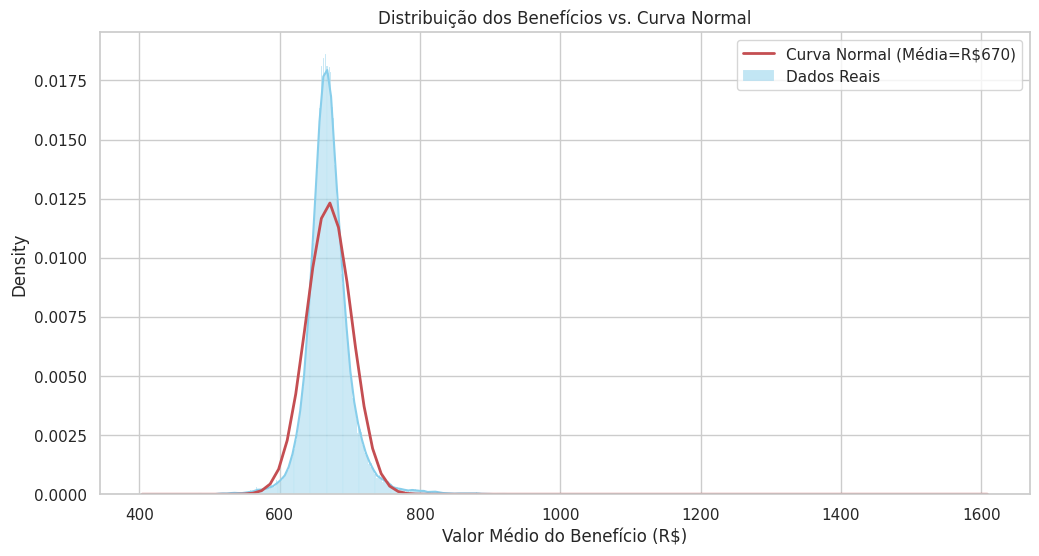

In [15]:
plt.figure(figsize=(12, 6))

# Plotando os dados reais (Histograma)
sns.histplot(df['PBF_Vlr_Médio_Beneficiário'], kde=True, stat="density", color="skyblue", label="Dados Reais")

# Calculando a Curva Normal Teórica (Matemática)
media_real = df['PBF_Vlr_Médio_Beneficiário'].mean()
desvio_real = df['PBF_Vlr_Médio_Beneficiário'].std()

xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, media_real, desvio_real)

# Plotando a linha vermelha da Normal
plt.plot(x, p, 'r', linewidth=2, label=f'Curva Normal (Média=R${media_real:.0f})')
plt.title('Distribuição dos Benefícios vs. Curva Normal')
plt.xlabel('Valor Médio do Benefício (R$)')
plt.legend()
plt.show()

# Boxplot dos 5 Municípios com Maior Média de Benefício
  Ao analisar este boxplot, você pode entender não apenas a média (que já foi vista no ranking), mas também a dispersão e a variabilidade dos valores médios de benefício dentro de cada um desses municípios de destaque. Por exemplo, um boxplot curto indica que os valores de benefício naquele município são bem consistentes, enquanto um boxplot longo ou com muitos outliers indica uma maior variabilidade ou valores extremos. Isso pode revelar diferenças internas na forma como o benefício é distribuído, mesmo em municípios que têm uma média alta.

/tmp/ipython-input-2963555799.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




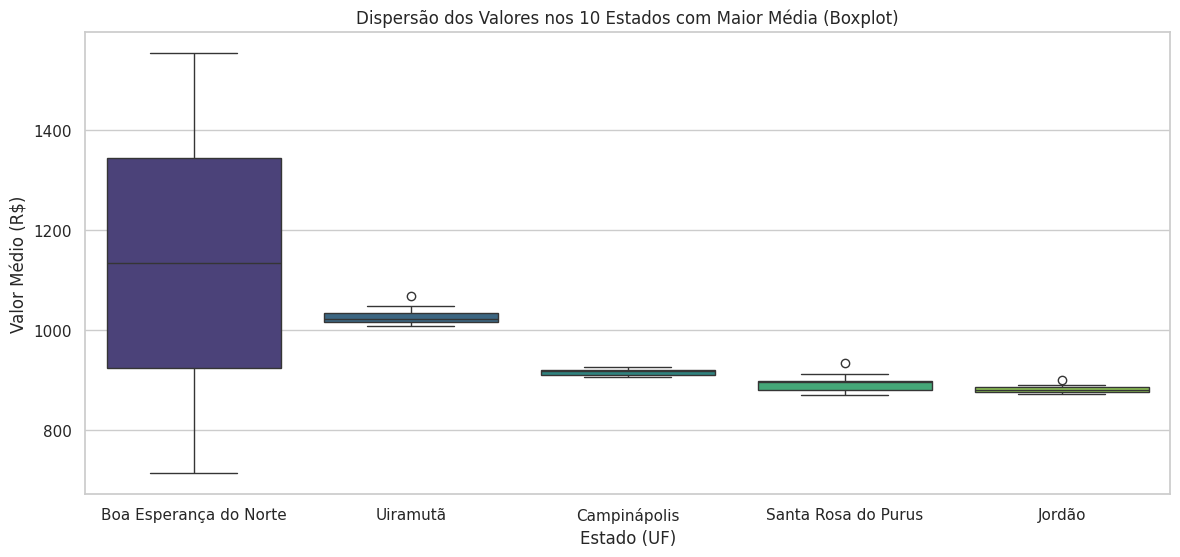

In [21]:
top_estados = df.groupby('Nome')['PBF_Vlr_Médio_Beneficiário'].mean().nlargest(5).index
df_top10 = df[df['Nome'].isin(top_estados)]

plt.figure(figsize=(14, 6))
sns.boxplot(x='Nome', y='PBF_Vlr_Médio_Beneficiário', data=df_top10, palette="viridis", order=top_estados)
plt.title('Dispersão dos Valores nos 5 Municipios com Maior Média (Boxplot)')
plt.ylabel('Valor Médio (R$)')
plt.xlabel('Municipios')
plt.show()

# Matriz de Correlação
 Você pode ver que Quantidade_Famílias_Beneficiárias e Valor_Repassado_Bolsa_Família têm uma correlação de 1.00. Isso é esperado, pois o valor total repassado é diretamente proporcional ao número de famílias beneficiárias (quanto mais famílias, maior o valor total repassado, assumindo um valor médio por família). Isso indica uma relação linear muito forte e positiva.

 Já a correlação entre PBF_Vlr_Médio_Beneficiário com as outras duas variáveis (Quantidade_Famílias_Beneficiárias e Valor_Repassado_Bolsa_Família) é muito baixa (0.03 e 0.04). Isso sugere que o valor médio do benefício por beneficiário não tem uma relação linear forte com o número de famílias ou com o valor total repassado. Em outras palavras, municípios com muitas famílias ou com alto valor total repassado não necessariamente têm um valor médio de benefício muito diferente daqueles com poucas famílias ou baixo valor total.

 Isso ajuda a entender que, embora o volume total de recursos e o número de famílias sejam grandes em alguns lugares, o valor individual do benefício se mantém relativamente estável ou segue outra lógica, o que é um achado importante para avaliar a distribuição do programa.

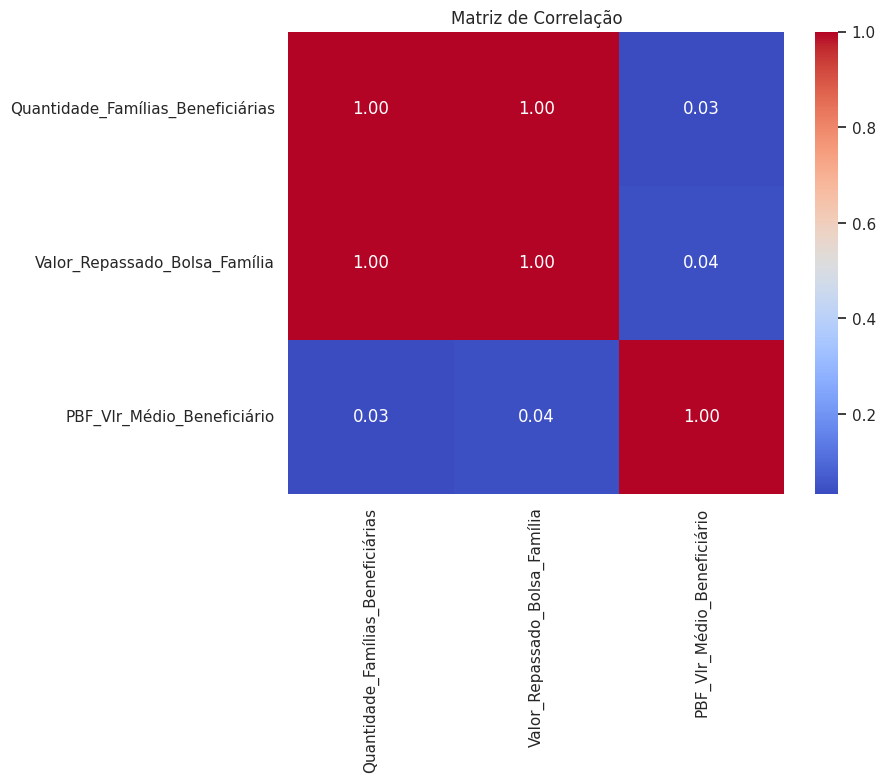

In [24]:
plt.figure(figsize=(8, 6))
# Selecionando colunas numéricas
colunas_numericas = ['Quantidade_Famílias_Beneficiárias', 'Valor_Repassado_Bolsa_Família', 'PBF_Vlr_Médio_Beneficiário']
matriz_corr = df[colunas_numericas].corr()

sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação')
plt.show()

# Disparidade: Comparação entre os Extremos (10% vs 80% vs 10%)
 O objetivo principal desta análise é visualizar a magnitude da disparidade nos valores médios dos benefícios do Bolsa Família. Ao comparar explicitamente a média dos 10% menores, dos 80% do meio e dos 10% maiores.

 isso mostra que há uma diferença de aproximadamente R$113.61 (732.99 - 619.38) entre a média dos 10% municípios que recebem os maiores benefícios e os 10% que recebem os menores, o que é um dado relevante para a análise da equidade do programa.

/tmp/ipython-input-2359135039.py:22: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




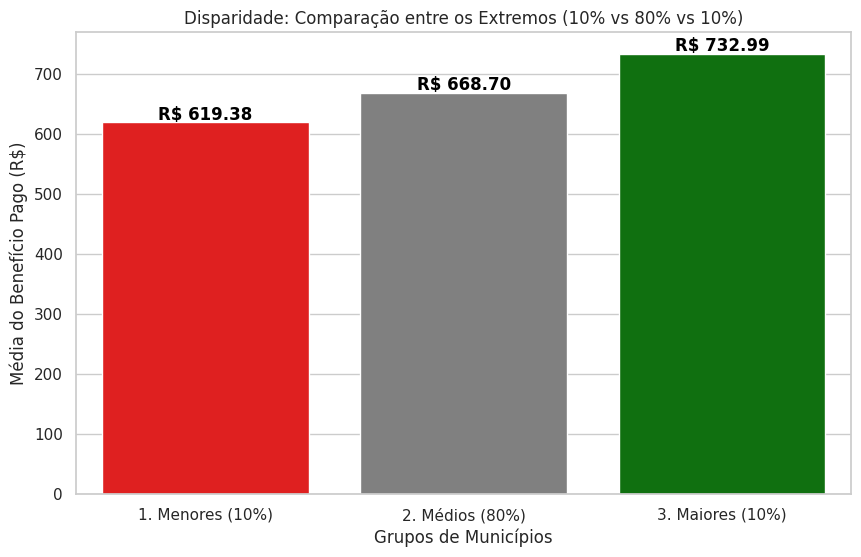

In [27]:
# Calculando os limites (Quantis)
corte_10_porcento = df['PBF_Vlr_Médio_Beneficiário'].quantile(0.10)
corte_90_porcento = df['PBF_Vlr_Médio_Beneficiário'].quantile(0.90)

# Função para classificar cada cidade
def classificar_faixa(valor):
    if valor <= corte_10_porcento:
        return '1. Menores (10%)'
    elif valor >= corte_90_porcento:
        return '3. Maiores (10%)'
    else:
        return '2. Médios (80%)'

# Criando a coluna de classificação
df['Faixa_Renda'] = df['PBF_Vlr_Médio_Beneficiário'].apply(classificar_faixa)

# Calculando a média de cada grupo para o gráfico
resumo_faixas = df.groupby('Faixa_Renda')['PBF_Vlr_Médio_Beneficiário'].mean().reset_index()

# Plotando o gráfico de barras comparativo
plt.figure(figsize=(10, 6))
grafico = sns.barplot(x='Faixa_Renda', y='PBF_Vlr_Médio_Beneficiário', data=resumo_faixas, palette=['red', 'gray', 'green'])

plt.title('Disparidade: Comparação entre os Extremos (10% vs 80% vs 10%)')
plt.ylabel('Média do Benefício Pago (R$)')
plt.xlabel('Grupos de Municípios')

# Colocando os valores em cima das barras
for i in range(len(resumo_faixas)):
    valor = resumo_faixas.loc[i, 'PBF_Vlr_Médio_Beneficiário']
    plt.text(i, valor + 5, f'R$ {valor:.2f}', ha='center', color='black', weight='bold')

plt.show()

# HISTOGRAMA DA MEDIA NACINAL DE VALORES PAGOS A BENEFICIARIOS.
O histograma mostra a distribuição dos valores médios do Bolsa Família pagos por município. As barras indicam a quantidade de municípios que se encaixam em cada faixa de valor médio. A curva suave (KDE) representa uma estimativa da densidade de probabilidade, ilustrando a forma geral da distribuição.

A linha vertical vermelha pontilhada indica a média nacional dos valores médios pagos, que é de aproximadamente R$689,83. A concentração das barras em torno dessa média sugere que a maioria dos municípios tem um valor médio de benefício relativamente próximo da média nacional.

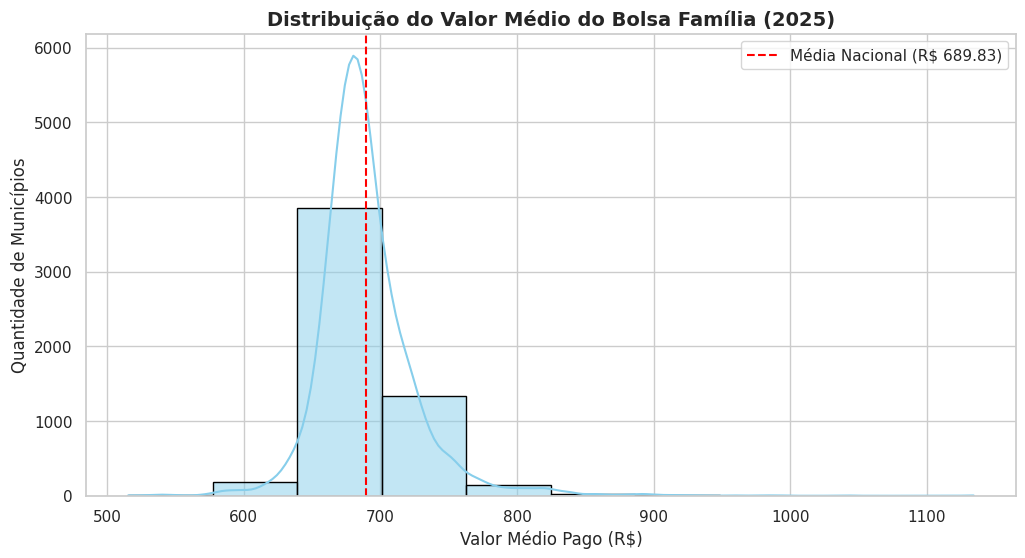

In [34]:
plt.figure(figsize=(12, 6))

# Criando o Histograma
sns.histplot(
    data=df,
    x='Valor_Medio',   # A coluna que queremos analisar (corrigido para 'Valor_Medio')
    kde=True,          # Adiciona a linha suave (curva de densidade)
    bins=10,           # Quantidade de barrinhas (intervalos)
    color='skyblue',   # Cor das barras
    edgecolor='black'  # Contorno das barras
)

# Enfeitando o gráfico
plt.title('Distribuição do Valor Médio do Bolsa Família (2025)', fontsize=14, fontweight='bold')
plt.xlabel('Valor Médio Pago (R$)', fontsize=12)
plt.ylabel('Quantidade de Municípios', fontsize=12)

# Adicionando uma linha vertical na Média (para referência visual)
media = df['Valor_Medio'].mean() # Corrigido para 'Valor_Medio'
plt.axvline(media, color='red', linestyle='--', label=f'Média Nacional (R$ {media:.2f})')

plt.legend() # Mostra a legenda da linha vermelha
plt.show()

# Considerações Finais:
Os dados do Bolsa Família para janeiro de 2025 demonstram a complexidade da distribuição de benefícios em um país de dimensões continentais como o Brasil. A capacidade do programa de direcionar recursos para regiões com maior necessidade e a relativa estabilidade do valor médio por beneficiário, independentemente do volume total de repasses, são pontos fortes. No entanto, as disparidades entre os municípios nos extremos de valores médios de benefício indicam áreas potenciais para futuras investigações e ajustes de políticas públicas, visando aprimorar ainda mais a equidade e eficácia do programa.